In [4]:
!git clone https://github.com/JusticeZzy/FunduSegmenter.git

%cd FunduSegmenter

d:\Projects\College\Rabcl\Segementation\FunduSegmenter\FunduSegmenter


fatal: destination path 'FunduSegmenter' already exists and is not an empty directory.


In [5]:
!python --version

Python 3.11.5


In [3]:
import torch
import torchvision

print("PyTorch:", torch.__version__)
print("Torchvision:", torchvision.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.5.1+cu121
Torchvision: 0.20.1+cu121
CUDA available: True
GPU: NVIDIA GeForce RTX 3050 Laptop GPU


In [6]:
import torch
from torch.nn import functional as F

from model.baselines.dunet import DUNet

DUNET_WEIGHTS = r"D:\Projects\College\Rabcl\DUNet_OD_CentreCrop_pretrained.pth"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

dunet = DUNet(
    input_channel=3,
    output_channel=2,
    base_channel=32
)

checkpoint = torch.load(
    DUNET_WEIGHTS,
    map_location="cpu",
    weights_only=False
)

dunet.load_state_dict(
    checkpoint["model"],
    strict=True
)

dunet = dunet.to(device)
dunet.eval()

print("✅ DUNet loaded")
print("Device:", device)

✅ DUNet loaded
Device: cuda


In [7]:
import pandas as pd
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

manifest = pd.read_csv(
    r"D:\Projects\College\Rabcl\BRSET_first_15_bilateral_patients_30_images_manifest.csv"
)

row = manifest.iloc[12]

image_path = os.path.join(
    r"D:\Projects\College\Rabcl\BRSET_sample",
    row["source_image"]
)

img_bgr = cv2.imread(image_path)

if img_bgr is None:
    raise FileNotFoundError(image_path)

img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

print("Image:", row["source_image"])
print("Shape:", img_rgb.shape)

Image: img00013.jpg
Shape: (874, 951, 3)


In [8]:
from utils.transform import validation_transform

transform = validation_transform(image_size=256)

transform_image, transform_both = transform

transformed = transform_image(image=img_rgb)
x = transformed["image"]

transformed = transform_both(image=x)
x = transformed["image"]

x = x.unsqueeze(0).to(device)

print("DUNet input:", x.shape)
print("dtype:", x.dtype)

c:\Users\DARSHAN\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


DUNet input: torch.Size([1, 3, 256, 256])
dtype: torch.float32


In [9]:
with torch.no_grad():
    y_pred = dunet(x)

print("Raw DUNet output:", y_pred.shape)

y_pred = F.interpolate(
    y_pred,
    size=(img_rgb.shape[0], img_rgb.shape[1]),
    mode="bicubic"
)

y_pred = torch.argmax(
    torch.softmax(y_pred, dim=1),
    dim=1
)

dunet_mask = y_pred.squeeze().cpu().numpy().astype(np.uint8)

print("DUNet mask:", dunet_mask.shape)
print("Unique values:", np.unique(dunet_mask))

Raw DUNet output: torch.Size([1, 2, 256, 256])
DUNet mask: (874, 951)
Unique values: [0 1]


In [10]:
min_area_ratio = 0.01
max_area_ratio = 0.30

# Convert to 0/255 exactly as official code
if dunet_mask.max() <= 1:
    dunet_mask = (dunet_mask * 255).astype(np.uint8)

contours, _ = cv2.findContours(
    dunet_mask,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

print("Number of contours:", len(contours))

best_circularity = -1
best_contour = None

H, W = img_rgb.shape[:2]

for contour in contours:

    area = cv2.contourArea(contour)

    area_ratio = area / (H * W)

    if area_ratio < min_area_ratio or area_ratio > max_area_ratio:
        continue

    perimeter = cv2.arcLength(contour, True)

    if perimeter == 0:
        circularity = 0
    else:
        circularity = (
            4 * np.pi * area /
            (perimeter * perimeter)
        )

    if circularity > best_circularity:
        best_circularity = circularity
        best_contour = contour

if best_contour is None:
    print("⚠️ No contour passed area filtering.")
    best_contour = max(contours, key=cv2.contourArea)

(x, y), radius = cv2.minEnclosingCircle(best_contour)

centre = (int(x), int(y))

print("✅ OD centre:", centre)
print("Radius:", radius)
print("Best circularity:", best_circularity)

Number of contours: 1
✅ OD centre: (731, 456)
Radius: 77.46360778808594
Best circularity: 0.8833010084842069


OD centre: (731, 456)
Square crop: (0, 56, 800, 856)
Crop size: 800 x 800


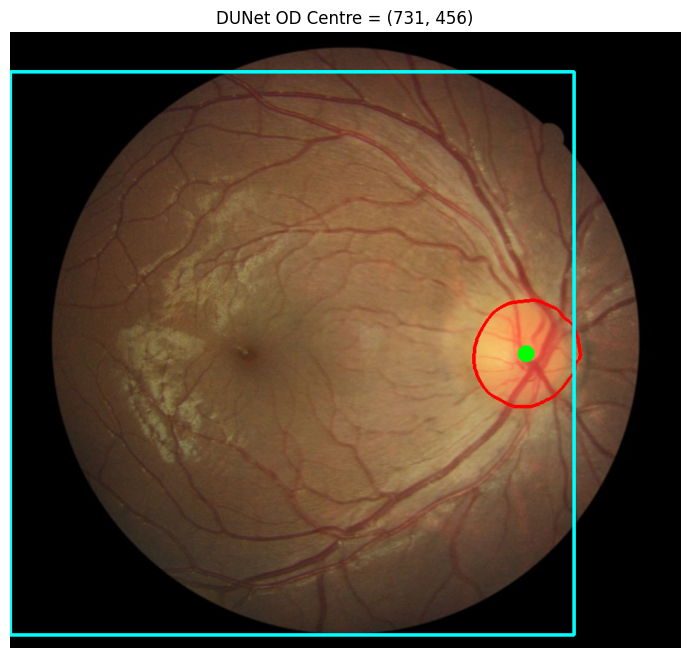

In [11]:
overlay = img_rgb.copy()

# Draw DUNet contour
cv2.drawContours(
    overlay,
    [best_contour],
    -1,
    (255, 0, 0),
    3
)

# Draw centre
cv2.circle(
    overlay,
    centre,
    12,
    (0, 255, 0),
    -1
)

# --------------------------------------------------
# Draw a TRUE 800 x 800 square crop boundary
# while keeping the entire square inside the image
# --------------------------------------------------

cx, cy = centre

crop_size = 800
half = crop_size // 2

img_h, img_w = img_rgb.shape[:2]

# Initial square centered on the detected OD
left = cx - half * 2
top = cy - half
right = left + crop_size
bottom = top + crop_size

# Shift horizontally if the square exceeds image bounds
if left < 0:
    left = 0
    right = crop_size

if right > img_w:
    right = img_w
    left = img_w - crop_size

# Shift vertically if the square exceeds image bounds
if top < 0:
    top = 0
    bottom = crop_size

if bottom > img_h:
    bottom = img_h
    top = img_h - crop_size

# Draw the corrected square
cv2.rectangle(
    overlay,
    (left, top),
    (right - 1, bottom - 1),
    (0, 255, 255),
    3
)

print("OD centre:", (cx, cy))
print("Square crop:", (left, top, right, bottom))
print("Crop size:", right - left, "x", bottom - top)

plt.figure(figsize=(10, 8))
plt.imshow(overlay)
plt.axis("off")
plt.title(f"DUNet OD Centre = ({cx}, {cy})")
plt.show()

In [12]:
# ============================================================
# DUNet OUTPUT -> BINARY OD MASK
# ============================================================

# dunet_mask contains:
#   0 = background
#   1 = OD
#
# Convert directly to:
#   0   = black background
#   255 = white OD

dunet_od_mask = np.where(
    dunet_mask > 0,
    255,
    0
).astype(np.uint8)

print("DUNet OD mask shape:", dunet_od_mask.shape)
print("Unique values:", np.unique(dunet_od_mask))

DUNet OD mask shape: (874, 951)
Unique values: [  0 255]


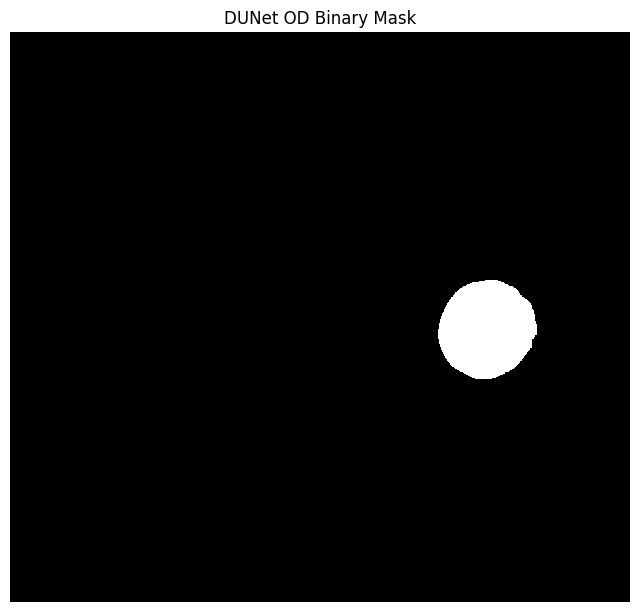

In [13]:
plt.figure(figsize=(8, 8))

plt.imshow(
    dunet_od_mask,
    cmap="gray",
    vmin=0,
    vmax=255,
    interpolation="nearest"
)

plt.title("DUNet OD Binary Mask")
plt.axis("off")

plt.show()

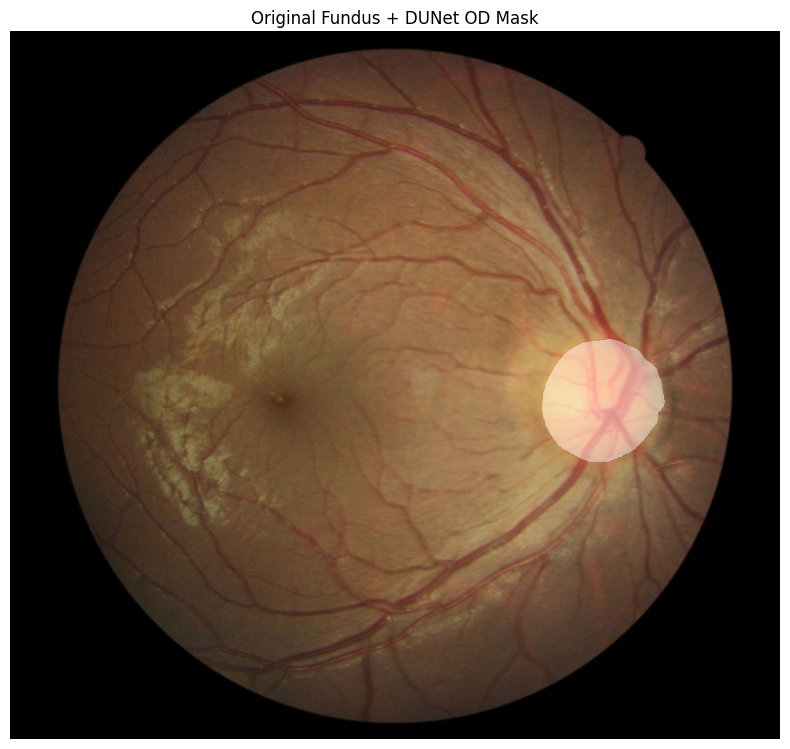

In [14]:
# ============================================================
# DUNet OD MASK OVERLAY ON ORIGINAL FUNDUS
# ============================================================

fig, ax = plt.subplots(figsize=(8, 8))

# Original fundus as background
ax.imshow(img_rgb)

# Create transparent overlay
overlay = np.zeros(
    (*dunet_od_mask.shape, 4),
    dtype=np.float32
)

# OD pixels
od_pixels = dunet_od_mask == 255

# White OD mask
overlay[od_pixels, 0] = 1.0
overlay[od_pixels, 1] = 1.0
overlay[od_pixels, 2] = 1.0

# Transparency
overlay[od_pixels, 3] = 0.45

# Overlay on original fundus
ax.imshow(overlay)

ax.set_title("Original Fundus + DUNet OD Mask")
ax.axis("off")

plt.tight_layout()
plt.show()

In [15]:
# ============================================================
# GENERATE DUNet OD MASKS FOR ALL BRSET SAMPLES
# ============================================================
#
# Output:
#
# masks_output/
# ├── patient_00001/
# │   ├── Left_OD.png
# │   └── Right_OD.png
# ├── patient_00002/
# │   ├── Left_OD.png
# │   └── Right_OD.png
# └── ...
#
# Mask:
#   255 = OD (white)
#     0 = background (black)
#
# The mask is kept at the ORIGINAL FUNDUS IMAGE resolution.
# ============================================================

import os
import cv2
import numpy as np
import pandas as pd
import torch
from torch.nn import functional as F
from tqdm.auto import tqdm


# ============================================================
# PATHS
# ============================================================

BRSET_DIR = r"D:\Projects\College\Rabcl\BRSET_sample"

MANIFEST_PATH = (
    r"D:\Projects\College\Rabcl"
    r"\BRSET_first_15_bilateral_patients_30_images_manifest.csv"
)

MASKS_OUTPUT = (
    r"D:\Projects\College\Rabcl\masks_output"
)


# ============================================================
# CREATE OUTPUT DIRECTORY
# ============================================================

os.makedirs(
    MASKS_OUTPUT,
    exist_ok=True
)


# ============================================================
# LOAD MANIFEST
# ============================================================

manifest = pd.read_csv(
    MANIFEST_PATH
)

print("Total images:", len(manifest))
print(
    "Total patients:",
    manifest["patient_id"].nunique()
)

print(
    "\nColumns:",
    manifest.columns.tolist()
)


# ============================================================
# DUNet INFERENCE FUNCTION
# ============================================================

def generate_dunet_od_mask(image_rgb):

    original_h, original_w = image_rgb.shape[:2]

    # --------------------------------------------------------
    # Same preprocessing used in your notebook
    # --------------------------------------------------------

    transform = validation_transform(
        image_size=256
    )

    transform_image, transform_both = transform

    transformed = transform_image(
        image=image_rgb
    )

    x = transformed["image"]

    transformed = transform_both(
        image=x
    )

    x = transformed["image"]

    x = x.unsqueeze(0).to(device)

    # --------------------------------------------------------
    # DUNet prediction
    # --------------------------------------------------------

    with torch.no_grad():

        y_pred = dunet(x)

    # --------------------------------------------------------
    # Resize prediction to ORIGINAL image dimensions
    # --------------------------------------------------------

    y_pred = F.interpolate(
        y_pred,
        size=(original_h, original_w),
        mode="bicubic"
    )

    # --------------------------------------------------------
    # Convert logits -> predicted class
    # --------------------------------------------------------

    y_pred = torch.argmax(
        torch.softmax(y_pred, dim=1),
        dim=1
    )

    dunet_mask = (
        y_pred
        .squeeze()
        .cpu()
        .numpy()
        .astype(np.uint8)
    )

    # --------------------------------------------------------
    # Convert DUNet output directly to binary OD mask
    #
    # 0 = background
    # 1 = OD
    #
    # OD       -> 255 WHITE
    # Background -> 0 BLACK
    # --------------------------------------------------------

    od_mask = np.where(
        dunet_mask > 0,
        255,
        0
    ).astype(np.uint8)

    # --------------------------------------------------------
    # Force exact binary values
    # --------------------------------------------------------

    od_mask[od_mask > 0] = 255

    return od_mask

Total images: 30
Total patients: 15

Columns: ['patient_id', 'image_id', 'eye_label', 'exam_eye', 'source_image', 'target_image', 'target_mask', 'quality', 'camera', 'vessels']


In [16]:
# ============================================================
# PROCESS ALL BRSET IMAGES
# ============================================================

success = 0
failed = 0

for _, row in tqdm(
    manifest.iterrows(),
    total=len(manifest),
    desc="Generating DUNet OD masks"
):

    # --------------------------------------------------------
    # Patient ID
    # --------------------------------------------------------

    patient_id = int(
        row["patient_id"]
    )

    patient_folder = os.path.join(
        MASKS_OUTPUT,
        f"patient_{patient_id:05d}"
    )

    # Create patient folder only if it doesn't exist
    os.makedirs(
        patient_folder,
        exist_ok=True
    )


    # --------------------------------------------------------
    # Image path
    # --------------------------------------------------------

    image_path = os.path.join(
        BRSET_DIR,
        row["source_image"]
    )

    # --------------------------------------------------------
    # Read image
    # --------------------------------------------------------

    img_bgr = cv2.imread(
        image_path
    )

    if img_bgr is None:

        print(
            f"\n❌ Could not read:"
            f" {image_path}"
        )

        failed += 1
        continue


    # --------------------------------------------------------
    # BGR -> RGB
    # --------------------------------------------------------

    img_rgb = cv2.cvtColor(
        img_bgr,
        cv2.COLOR_BGR2RGB
    )


    # --------------------------------------------------------
    # Generate DUNet OD mask
    # --------------------------------------------------------

    try:

        od_mask = generate_dunet_od_mask(
            img_rgb
        )

    except Exception as e:

        print(
            f"\n❌ Failed:"
            f" patient_{patient_id:05d}"
        )

        print("Image:", row["source_image"])
        print("Error:", e)

        failed += 1
        continue


    # --------------------------------------------------------
    # Eye label
    # --------------------------------------------------------

    eye = str(
        row["eye_label"]
    ).strip().lower()

    if eye == "left":
        eye_name = "Left"

    elif eye == "right":
        eye_name = "Right"

    else:

        print(
            f"\n⚠️ Unknown eye label: {eye}"
        )

        failed += 1
        continue


    # --------------------------------------------------------
    # FINAL FILE NAME
    # --------------------------------------------------------

    output_path = os.path.join(
        patient_folder,
        f"{eye_name}_OD.png"
    )


    # --------------------------------------------------------
    # Save PNG
    # --------------------------------------------------------

    success_write = cv2.imwrite(
        output_path,
        od_mask
    )

    if not success_write:

        print(
            f"\n❌ Could not save:"
            f" {output_path}"
        )

        failed += 1
        continue


    success += 1


# ============================================================
# SUMMARY
# ============================================================

print("\n")
print("=" * 60)
print("DUNet OD MASK GENERATION COMPLETE")
print("=" * 60)

print("Successful:", success)
print("Failed:", failed)
print("Total:", len(manifest))

print()
print("Output directory:")
print(MASKS_OUTPUT)

Generating DUNet OD masks: 100%|██████████| 30/30 [00:01<00:00, 28.07it/s]



DUNet OD MASK GENERATION COMPLETE
Successful: 30
Failed: 0
Total: 30

Output directory:
D:\Projects\College\Rabcl\masks_output


In [17]:
# ============================================================
# OD DUNet - TEST TIME AUGMENTATION (TTA)
# CONSISTENCY / REPRODUCIBILITY EVALUATION
# ============================================================

def tta_images_od(img_rgb):

    images = {}

    # --------------------------------------------------------
    # Original
    # --------------------------------------------------------

    images["original"] = img_rgb.copy()

    # --------------------------------------------------------
    # Brightness increase
    # --------------------------------------------------------

    brighter = cv2.convertScaleAbs(
        img_rgb,
        alpha=1.0,
        beta=15
    )

    images["brightness_up"] = brighter

    # --------------------------------------------------------
    # Brightness decrease
    # --------------------------------------------------------

    darker = cv2.convertScaleAbs(
        img_rgb,
        alpha=1.0,
        beta=-15
    )

    images["brightness_down"] = darker

    # --------------------------------------------------------
    # Mild contrast increase
    # --------------------------------------------------------

    contrast = cv2.convertScaleAbs(
        img_rgb,
        alpha=1.10,
        beta=0
    )

    images["contrast"] = contrast

    # --------------------------------------------------------
    # Mild Gaussian noise
    # --------------------------------------------------------

    noise = np.random.normal(
        0,
        5,
        img_rgb.shape
    )

    noisy = np.clip(
        img_rgb.astype(np.float32) + noise,
        0,
        255
    ).astype(np.uint8)

    images["noise"] = noisy

    return images

In [ ]:
# ============================================================
# DUNet OD PREDICTION FUNCTION
# ============================================================

def predict_dunet_od_mask(image_rgb):

    original_h, original_w = image_rgb.shape[:2]

    # --------------------------------------------------------
    # Same preprocessing as existing DUNet pipeline
    # --------------------------------------------------------

    transform = validation_transform(
        image_size=256
    )

    transform_image, transform_both = transform

    transformed = transform_image(
        image=image_rgb
    )

    x = transformed["image"]

    transformed = transform_both(
        image=x
    )

    x = transformed["image"]

    x = x.unsqueeze(0).to(device)

    # --------------------------------------------------------
    # DUNet inference
    # --------------------------------------------------------

    with torch.no_grad():

        y_pred = dunet(x)

    # --------------------------------------------------------
    # Restore original resolution
    # --------------------------------------------------------

    y_pred = F.interpolate(
        y_pred,
        size=(original_h, original_w),
        mode="bicubic"
    )

    # --------------------------------------------------------
    # Convert logits -> class
    # --------------------------------------------------------

    y_pred = torch.argmax(
        torch.softmax(y_pred, dim=1),
        dim=1
    )

    mask = (
        y_pred
        .squeeze()
        .cpu()
        .numpy()
        .astype(np.uint8)
    )

    # --------------------------------------------------------
    # Convert to binary OD mask
    #
    # 0   = background
    # 255 = OD
    # --------------------------------------------------------

    od_mask = np.where(
        mask > 0,
        255,
        0
    ).astype(np.uint8)

    return od_mask

In [ ]:
# ============================================================
# TTA CONSISTENCY METRICS
# ============================================================

def dice_score(mask_a, mask_b):

    mask_a = mask_a.astype(bool)
    mask_b = mask_b.astype(bool)

    intersection = np.logical_and(
        mask_a,
        mask_b
    ).sum()

    denominator = (
        mask_a.sum() +
        mask_b.sum()
    )

    if denominator == 0:
        return 1.0

    return (
        2.0 * intersection /
        denominator
    )


def iou_score(mask_a, mask_b):

    mask_a = mask_a.astype(bool)
    mask_b = mask_b.astype(bool)

    intersection = np.logical_and(
        mask_a,
        mask_b
    ).sum()

    union = np.logical_or(
        mask_a,
        mask_b
    ).sum()

    if union == 0:
        return 1.0

    return intersection / union

In [ ]:
# ============================================================
# SINGLE IMAGE TTA TEST
# ============================================================

tta = tta_images_od(img_rgb)

tta_masks = {}

for name, transformed_img in tta.items():

    tta_masks[name] = predict_dunet_od_mask(
        transformed_img
    )

print("TTA predictions generated:")
print(list(tta_masks.keys()))

In [ ]:
# ============================================================
# PAIRWISE TTA CONSISTENCY
# ============================================================

names = list(tta_masks.keys())

dice_values = []
iou_values = []

for i in range(len(names)):

    for j in range(i + 1, len(names)):

        a = tta_masks[names[i]]
        b = tta_masks[names[j]]

        dice = dice_score(a, b)
        iou = iou_score(a, b)

        dice_values.append(dice)
        iou_values.append(iou)

        print(
            f"{names[i]:18s} vs "
            f"{names[j]:18s} | "
            f"Dice = {dice:.4f} | "
            f"IoU = {iou:.4f}"
        )

print("\nMean TTA Dice:", np.mean(dice_values))
print("Mean TTA IoU :", np.mean(iou_values))
print("Min TTA Dice :", np.min(dice_values))
print("Min TTA IoU  :", np.min(iou_values))

In [ ]:
# ============================================================
# OD AREA STABILITY
# ============================================================

def mask_area(mask):

    return np.sum(mask > 0)


areas = {}

for name, mask in tta_masks.items():

    areas[name] = mask_area(mask)

print("\nOD areas:")

for name, area in areas.items():

    print(
        f"{name:18s}: {area:,} pixels"
    )


area_values = np.array(
    list(areas.values()),
    dtype=np.float64
)

mean_area = np.mean(area_values)
std_area = np.std(area_values)

area_cv = (
    std_area / mean_area
    if mean_area > 0
    else 0
)

print("\nMean OD area:", mean_area)
print("Std OD area :", std_area)
print("Area CV     :", area_cv)

In [ ]:
# ============================================================
# OD CENTROID
# ============================================================

def get_mask_centroid(mask):

    ys, xs = np.where(mask > 0)

    if len(xs) == 0:
        return None

    return (
        float(np.mean(xs)),
        float(np.mean(ys))
    )


centroids = {}

for name, mask in tta_masks.items():

    centroids[name] = get_mask_centroid(mask)

print("\nOD centroids:")

for name, centroid in centroids.items():

    print(
        f"{name:18s}: {centroid}"
    )

In [ ]:
# ============================================================
# CENTROID DISPLACEMENT
# ============================================================

original_centroid = centroids["original"]

centroid_displacements = {}

if original_centroid is not None:

    ox, oy = original_centroid

    for name, centroid in centroids.items():

        if centroid is None:

            centroid_displacements[name] = np.nan
            continue

        cx, cy = centroid

        distance = np.sqrt(
            (cx - ox) ** 2 +
            (cy - oy) ** 2
        )

        centroid_displacements[name] = distance

print("\nCentroid displacement from original:")

for name, distance in centroid_displacements.items():

    print(
        f"{name:18s}: {distance:.2f} pixels"
    )

In [ ]:
# ============================================================
# TTA EVALUATION - ALL BRSET IMAGES
# ============================================================

tta_results = []

for _, row in tqdm(
    manifest.iterrows(),
    total=len(manifest),
    desc="Running OD TTA evaluation"
):

    patient_id = int(row["patient_id"])
    eye = str(row["eye_label"]).strip().lower()

    image_path = os.path.join(
        BRSET_DIR,
        row["source_image"]
    )

    img_bgr = cv2.imread(image_path)

    if img_bgr is None:
        continue

    img_rgb = cv2.cvtColor(
        img_bgr,
        cv2.COLOR_BGR2RGB
    )

    # --------------------------------------------------------
    # Generate TTA images
    # --------------------------------------------------------

    tta = tta_images_od(img_rgb)

    # --------------------------------------------------------
    # Generate OD masks
    # --------------------------------------------------------

    tta_masks = {}

    for name, transformed_img in tta.items():

        tta_masks[name] = predict_dunet_od_mask(
            transformed_img
        )

    # --------------------------------------------------------
    # Pairwise Dice / IoU
    # --------------------------------------------------------

    names = list(tta_masks.keys())

    dice_values = []
    iou_values = []

    for i in range(len(names)):

        for j in range(i + 1, len(names)):

            dice_values.append(
                dice_score(
                    tta_masks[names[i]],
                    tta_masks[names[j]]
                )
            )

            iou_values.append(
                iou_score(
                    tta_masks[names[i]],
                    tta_masks[names[j]]
                )
            )

    # --------------------------------------------------------
    # Area stability
    # --------------------------------------------------------

    areas = [
        mask_area(mask)
        for mask in tta_masks.values()
    ]

    mean_area = np.mean(areas)
    std_area = np.std(areas)

    area_cv = (
        std_area / mean_area
        if mean_area > 0
        else 0
    )

    # --------------------------------------------------------
    # Centroid stability
    # --------------------------------------------------------

    centroids = [
        get_mask_centroid(mask)
        for mask in tta_masks.values()
    ]

    original_centroid = centroids[0]

    centroid_distances = []

    if original_centroid is not None:

        ox, oy = original_centroid

        for centroid in centroids[1:]:

            if centroid is None:
                continue

            cx, cy = centroid

            distance = np.sqrt(
                (cx - ox) ** 2 +
                (cy - oy) ** 2
            )

            centroid_distances.append(distance)

    mean_centroid_shift = (
        np.mean(centroid_distances)
        if centroid_distances
        else np.nan
    )

    # --------------------------------------------------------
    # Save result
    # --------------------------------------------------------

    tta_results.append({

        "patient_id": patient_id,
        "eye": eye,

        "mean_tta_dice":
            np.mean(dice_values),

        "min_tta_dice":
            np.min(dice_values),

        "mean_tta_iou":
            np.mean(iou_values),

        "min_tta_iou":
            np.min(iou_values),

        "mean_od_area":
            mean_area,

        "std_od_area":
            std_area,

        "area_cv":
            area_cv,

        "mean_centroid_shift_px":
            mean_centroid_shift
    })


tta_results = pd.DataFrame(
    tta_results
)

display(tta_results)